# Formula 1 Strategy Analysis 

Author: Brian Ndungu

Project Type: Data Science - Sports Analytics

Dataset: F1 Strategy Dataset v4

Methodology: CRISP-DM 

### Project Overview

Formula 1 is a sport driven by strategy, tyre management, race pace, pit stops, and driver decisions. In this project, we analyze Formula 1 race strategy data to uncover patterns that influence performance.

The notebook follows the CRISP-DM methodology, a widely adopted framework in data science projects.

### CRISP-DM Methodology

The CRISP-DM process contains:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Exploratory Data Analysis (EDA)
5. Modeling
6. Evaluation
7. Deployment & Recommendations

# 1.Business Understanding
### Problem Statement

Formula 1 teams constantly optimize:

1. Tyre strategies
2. Pit stop timing
3. Race pace
4. Position gains/losses
5. Degradation management

The goal of this project is to:

1. Understand how tyre compounds affect lap performance
2. Analyze degradation trends
3. Predict lap times using machine learning
4. Discover strategic insights from race data

### Objectives

1. Explore race strategy trends
2. Analyze tyre degradation
3. Compare compounds and stint performance
4. Predict lap times using ML models
5. Generate insights suitable for teams and analysts

# 2. DATA UNDERSTANDING

In [95]:
# import libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# models

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings('ignore')

In [96]:
# data loading

df = pd.read_csv('f1_strategy_dataset_v4.csv')
df

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101366,ZHO,52,HARD,3,29.0,12,103.373,United States Grand Prix,2022,26.850,-90.264,0,0,0.722222,0.852941,2.0
101367,ZHO,53,HARD,3,30.0,13,105.200,United States Grand Prix,2022,27.061,-88.437,0,0,0.736111,0.882353,1.0
101368,ZHO,54,HARD,3,31.0,13,104.102,United States Grand Prix,2022,27.149,-89.535,0,0,0.750000,0.911765,0.0
101369,ZHO,55,HARD,3,32.0,14,103.812,United States Grand Prix,2022,4.428,-89.825,0,0,0.763889,0.941176,-1.0


In [97]:
df.shape

(101371, 16)

In [98]:
df.columns

Index(['Driver', 'LapNumber', 'Compound', 'Stint', 'TyreLife', 'Position',
       'LapTime (s)', 'Race', 'Year', 'LapTime_Delta',
       'Cumulative_Degradation', 'PitStop', 'PitNextLap', 'RaceProgress',
       'Normalized_TyreLife', 'Position_Change'],
      dtype='object')

In [99]:
df.dtypes

Driver                     object
LapNumber                   int64
Compound                   object
Stint                       int64
TyreLife                  float64
Position                    int64
LapTime (s)               float64
Race                       object
Year                        int64
LapTime_Delta             float64
Cumulative_Degradation    float64
PitStop                     int64
PitNextLap                  int64
RaceProgress              float64
Normalized_TyreLife       float64
Position_Change           float64
dtype: object

In [100]:
df.duplicated().sum()

0

# 3. DATA PREPARATION

#### Handle Missing Values

we preserve the rows by replacing missing tyre compounds with UNKNOWN.

In [101]:
df.isnull().sum()

Driver                     0
LapNumber                  0
Compound                  66
Stint                      0
TyreLife                   0
Position                   0
LapTime (s)                0
Race                       0
Year                       0
LapTime_Delta              0
Cumulative_Degradation     0
PitStop                    0
PitNextLap                 0
RaceProgress               0
Normalized_TyreLife        0
Position_Change            0
dtype: int64

In [102]:
print(df['Compound'].unique())

['MEDIUM' 'HARD' 'SOFT' 'INTERMEDIATE' 'WET' nan]


In [103]:
# Fill missing Compound values
df['Compound'] = df['Compound'].fillna('UNKNOWN')

# Verify
print("\nUpdated Compound Values:")
print(df['Compound'].unique())


Updated Compound Values:
['MEDIUM' 'HARD' 'SOFT' 'INTERMEDIATE' 'WET' 'UNKNOWN']


In [104]:
df.describe()

,LapNumber,Stint,TyreLife,Position,LapTime (s),Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
count,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000
mean,30.444841,2.046394,14.549339,9.759132,92.587188,2023.589685,-0.203891,-29.550051,0.251581,0.254797,0.432618,0.386521,-0.004636
std,18.146942,0.948797,10.313385,5.406456,33.231414,1.098518,45.344910,70.235759,0.433924,0.435749,0.258129,0.259906,3.912725
min,1.000000,1.000000,1.000000,1.000000,67.012000,2022.000000,-2403.895000,-274.564000,0.000000,0.000000,0.012821,0.012821,-18.000000
25%,15.000000,1.000000,7.000000,5.000000,82.021000,2023.000000,-7.253000,-51.054500,0.000000,0.000000,0.210526,0.172414,-2.000000
50%,30.000000,2.000000,13.000000,10.000000,91.167000,2024.000000,-0.027000,-21.678000,0.000000,0.000000,0.421053,0.333333,0.000000
75%,45.000000,3.000000,20.000000,14.000000,99.356000,2025.000000,5.705000,-3.725500,1.000000,1.000000,0.631579,0.562500,2.000000
max,78.000000,8.000000,78.000000,20.000000,2526.253000,2025.000000,2433.472000,2412.431000,1.000000,1.000000,1.000000,1.000000,18.000000


In [105]:
# feature engineering

df['Degradation_Per_Lap'] = (
    df['Cumulative_Degradation'] / (df['LapNumber'] + 1)
)

df.head()

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change,Degradation_Per_Lap
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0,0.000000
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0,-2.355000
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0,-2.214250
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0,-1.806800
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0,-1.533833


In [106]:
# encoding categorical variables

encoder = LabelEncoder()

categorical_columns = ['Driver', 'Compound', 'Race']
for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change,Degradation_Per_Lap
0,0,1,2,1,2.0,17,100.625,0,2023,0.000,0.000,0,0,0.017241,0.117647,0.0,0.000000
1,0,2,2,1,3.0,18,93.560,0,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0,-2.355000
2,0,3,2,1,4.0,18,91.768,0,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0,-2.214250
3,0,4,2,1,5.0,18,91.591,0,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0,-1.806800
4,0,5,2,1,6.0,18,91.422,0,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0,-1.533833


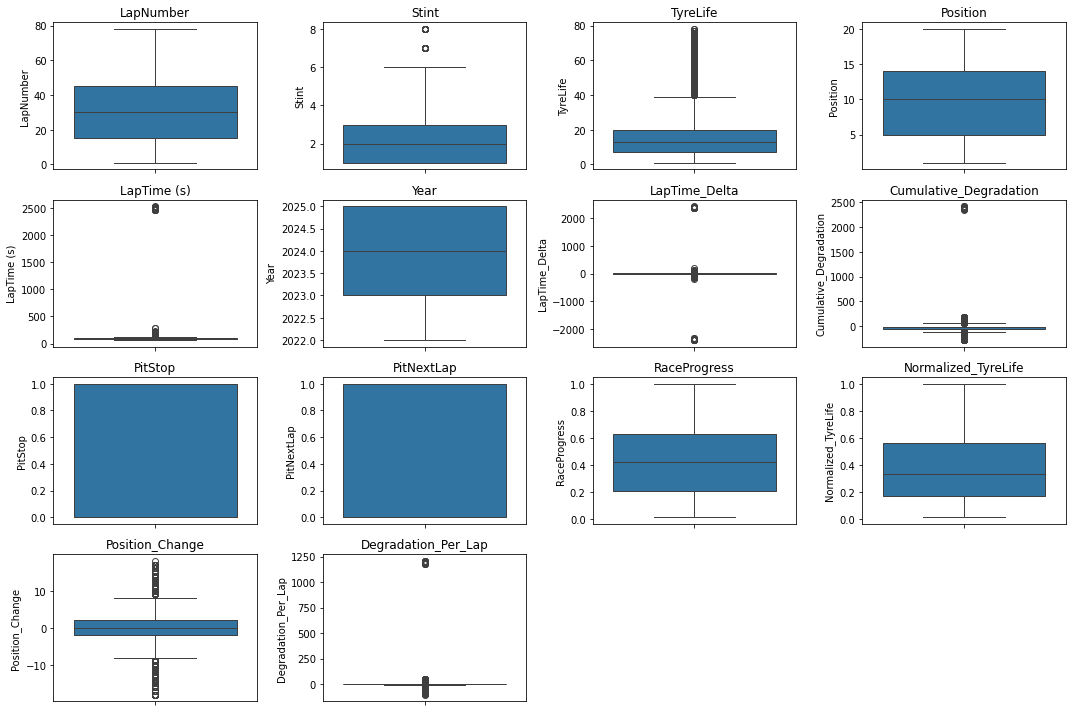

In [107]:
# check outliers
num_col = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15,10))

for i, col in enumerate(num_col, 1):
    plt.subplot(4,4,i)
    sns.boxplot(y=df[col])
    plt.title(col)
    
plt.tight_layout()
plt.show()

# 4. EXPLORATORY DATA ANALYSIS (EDA)


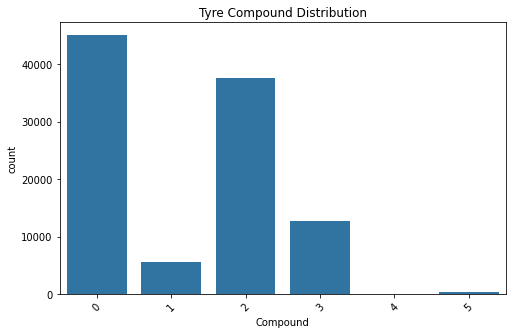

In [108]:
# Tyre Compound Distribution - checking outliers

plt.figure(figsize=(8,5))
sns.countplot(x=df['Compound'])
plt.title("Tyre Compound Distribution")
plt.xticks(rotation=45)
plt.show()


### Insight

This chart shows which tyre compounds were used most frequently during races.

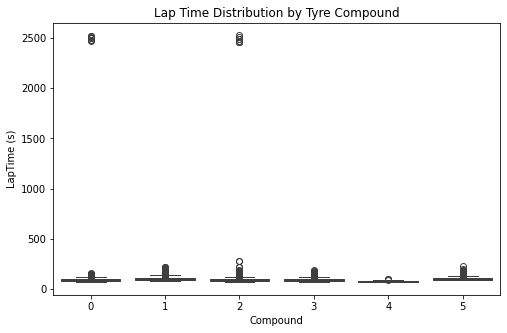

In [109]:
# Average Lap Time by Compound

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Compound', y='LapTime (s)')
plt.title('Lap Time Distribution by Tyre Compound')
plt.show()

### Insight

Different tyre compounds produce different performance levels.

- Soft tyres generally offer faster laps.
- Hard tyres provide consistency.
- Medium tyres balance speed and durability.

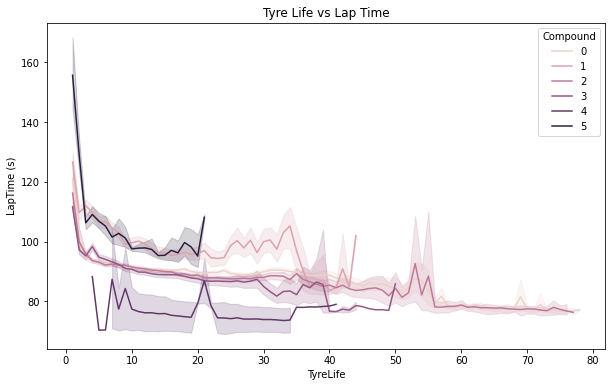

In [110]:
# Tyre Degradation Analysis

plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='TyreLife', y='LapTime (s)', hue='Compound')
plt.title('Tyre Life vs Lap Time')
plt.show()

### Insight

As tyre life increases:

- Lap times gradually worsen
- Performance degradation becomes visible
- Strategy timing becomes critical

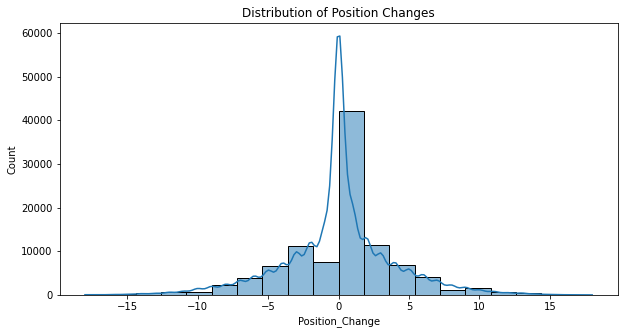

In [111]:
# Position Changes During Race

plt.figure(figsize=(10,5))
sns.histplot(df['Position_Change'], bins=20, kde=True)
plt.title('Distribution of Position Changes')
plt.show()

### Insight

Most drivers maintain position stability, while a smaller group gains or loses multiple places.

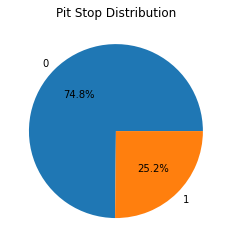

In [112]:
# Pit Stop Analysis

pit_counts = df['PitStop'].value_counts()

plt.figure(figsize=(6,4))
plt.pie(pit_counts, labels=pit_counts.index, autopct='%1.1f%%')
plt.title('Pit Stop Distribution')
plt.show()

### Insight

Pit stop frequency directly influences race strategy and tyre management.

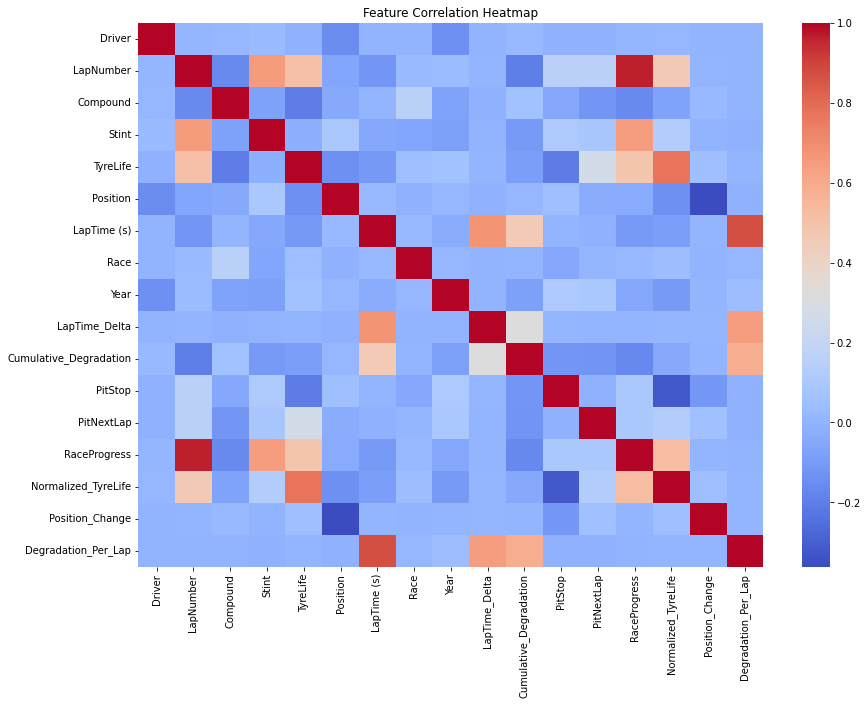

In [113]:
# check correlation

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation,
    cmap='coolwarm',
    annot=False
)

plt.title("Feature Correlation Heatmap")
plt.show()

# 5. MODELING

Target variable - LapTime

In [114]:
X = df.drop('LapTime (s)', axis=1)
y = df['LapTime (s)']

print(X.shape)
print(y.shape)

(101371, 16)
(101371,)


In [115]:
# Train-Test Split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)

(81096, 16)
(20275, 16)


In [116]:
# feature scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(81096, 16)
(20275, 16)


## MODEL 1  LINEAR REGRESSION

In [117]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)

lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_mse = mean_squared_error(y_test, lr_predictions)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_predictions)

print("LINEAR REGRESSION RESULTS")
print("MAE :", lr_mae)
print("MSE :", lr_mse)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

LINEAR REGRESSION RESULTS
MAE : 9.722848128216464
MSE : 227.63642836225642
RMSE: 15.087625007344808
R2 Score: 0.7022241385026353


## MODEL 2  DECISION TREE

In [118]:
dt_model = DecisionTreeRegressor(
    random_state=42
)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_predictions)

print("DECISION TREE RESULTS")
print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE:", dt_rmse)
print("R2 Score:", dt_r2)

DECISION TREE RESULTS
MAE : 1.2545710974106044
MSE : 16.87537755270037
RMSE: 4.107965135282963
R2 Score: 0.9779249739375993


## MODEL 3  RANDOM FOREST

In [119]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_predictions)

print("RANDOM FOREST RESULTS")
print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

RANDOM FOREST RESULTS
MAE : 1.0599494929716402
MSE : 9.375871340251676
RMSE: 3.0620044644401934
R2 Score: 0.9877352311942406


# 6. EVALUATION

### model comparision

In [120]:
model_results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],
    
    'MAE': [
        lr_mae,
        dt_mae,
        rf_mae
    ],
    
    'RMSE': [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],
    
    'R2 Score': [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

model_results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.722848,15.087625,0.702224
1,Decision Tree,1.254571,4.107965,0.977925
2,Random Forest,1.059949,3.062004,0.987735


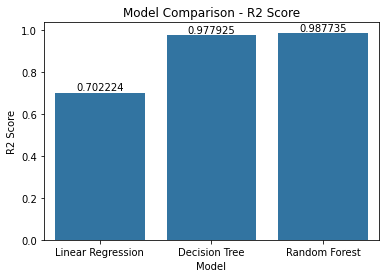

In [121]:
ax = sns.barplot(
    data=model_results,
    x='Model',
    y='R2 Score'
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Model Comparison - R2 Score")
plt.show()

### Model Performance Summary

- Linear Regression R2 Score: 0.70
- Decision Tree R2 Score: 0.97
- Random Forest R2 Score: 0.98

Random Forest achieved the best performance.

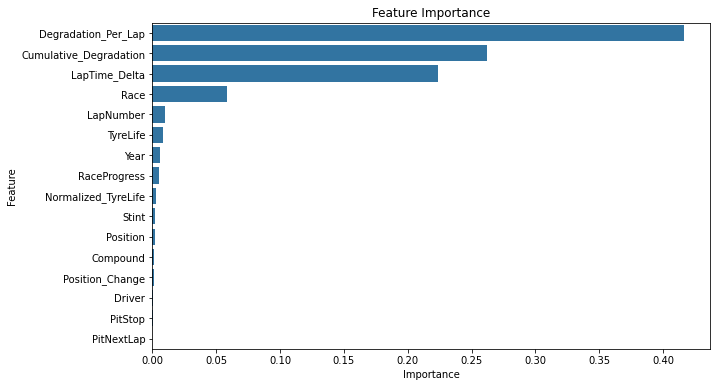

In [122]:
# Feature importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})
importance = importance.sort_values(
    by='Importance',
    ascending=False
)
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)
plt.title("Feature Importance")
plt.show()

#### Insight

The most influential factors affecting lap times can now be identified.

top features include:

1. Degradation
2. LapTime
3. Race
4. Lap number
5. Year

# 7. DEPLOYMENT AND RECOMMENDATIONS

### Final Key Insights

1. Tyre degradation strongly impacts lap times.
2. Random Forest captured non-linear racing patterns best.
3. Pit stop timing influences race position changes.
4. Feature engineering improved predictive performance.
5. Data science can support strategic racing decisions.

### Business Recommendations

Formula 1 teams can use these insights to:

- Optimize tyre strategies
- Predict performance degradation
- Improve pit stop timing
- Enhance race simulations
- Support real-time strategic decisions

### Future Improvements

Potential next steps:

1. Add weather data
2. Include sector times
3. Predict pit stop windows
4. Build live race dashboards
5. Develop AI-driven strategy simulators

### Final Conclusion

This project successfully demonstrated how Formula 1 race strategy data can be analyzed using the CRISP-DM framework.

Key takeaways:

- Tyre degradation significantly affects lap performance
- Race strategy variables influence outcomes
- Machine learning can predict lap times effectively
- Random Forest captures complex racing patterns better

This project combines:

1. Sports analytics
2. Data science
3. Machine learning
4. Strategic decision-making